download data: https://www.nyc.gov/site/tlc/about/about-tlc.page

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import pickle

from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
import xgboost as xgb

from sklearn.metrics import root_mean_squared_error

import mlflow
from mlflow.tracking import MlflowClient

/home/niltonpegass/.local/share/virtualenvs/repositorio_local-WRNaRh7k/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


#### MLflow UI

MLflow provides a web-based User Interface (UI) to visualize and compare all your experiment runs. It makes it easier to analyze metrics, parameters, models, and artifacts in one place.

#### RUNNING MLflow UI LOCALLY

To launch the MLflow UI locally, run the following command:

> `mlflow server --backend-store-uri sqlite:///mlflow.db --host 127.0.0.1 --port 5000`

This command starts a local server and opens the MLflow dashboard at **`http://127.0.0.1:5000`**

---

In addition to the UI, an interface that is introduced in the course and used to automate processes is the Tracking API. Initialized through:

In [2]:
# MLFLOW_TRACKING_URI = "http://127.0.0.1:5000/"

# mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
# mlflow.set_experiment("nyc-new-brand-experiment_first")

# client = MlflowClient(tracking_uri=MLFLOW_TRACKING_URI)

In [3]:
# ==============================================================================
# MLflow Configuration
# ==============================================================================
# MLflow is a tool that helps you track machine learning experiments.
# Think of it as a "lab notebook" that automatically records what you tried,
# what settings you used, and what results you got - so you can compare runs later.
# ==============================================================================


# ------------------------------------------------------------------------------
# Step 1: Choose where MLflow will store its data (the "Tracking URI")
# ------------------------------------------------------------------------------
# The Tracking URI tells MLflow where to save experiment records.
# There are two common options:

# OPTION A - MLflow Server (commented out here):
#   Starts a full web server in the background (run `mlflow server` in the terminal first).
#   Good for teams sharing results, but uses more RAM and requires the server to be running.
# MLFLOW_TRACKING_URI = "http://127.0.0.1:5000/"

# OPTION B - SQLite local file (active option):
#   Saves everything directly into a local file called "mlflow.db".
#   No server needed. Lightweight and perfect for solo/local development.
MLFLOW_TRACKING_URI = "sqlite:///mlflow.db"


# ------------------------------------------------------------------------------
# Step 2: Apply the Tracking URI to the MLflow session
# ------------------------------------------------------------------------------
# This line tells the MLflow library: "use THIS location to store and read data."
# It must be called before logging any runs or creating experiments.
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)


# ------------------------------------------------------------------------------
# Step 3: Name and activate the Experiment
# ------------------------------------------------------------------------------
# An "experiment" in MLflow is a named container that groups related runs together.
# For example, all the times you train a model on the NYC dataset go under one experiment.
# If this experiment name doesn't exist yet, MLflow creates it automatically.
mlflow.set_experiment("nyc-new-brand-experiment_first")


# ------------------------------------------------------------------------------
# Step 4: Create an MLflow Client
# ------------------------------------------------------------------------------
# The MlflowClient gives you programmatic (code-level) access to MLflow's data.
# While mlflow.set_experiment() is great for logging during training,
# the client lets you *query and manage* experiments, runs, and metrics after the fact.
# Example uses: listing all runs, comparing metrics, deleting old experiments.
client = MlflowClient(tracking_uri=MLFLOW_TRACKING_URI)

In [4]:
import pyarrow.parquet as pq

nrows = 10000 # ex: 10000 for testing, None for all rows
df = pq.read_table('data/yellow_tripdata_2023-01.parquet').slice(0, nrows).to_pandas()

df['duration'] = df.tpep_dropoff_datetime - df.tpep_pickup_datetime
df.duration = df.duration.apply(lambda td: td.total_seconds() / 60)

df = df[(df.duration >= 1) & (df.duration <= 60)]

categorical = ['PULocationID', 'DOLocationID']
numerical = ['trip_distance']

df[categorical] = df[categorical].astype(str)

In [5]:
train_dicts = df[categorical + numerical].to_dict(orient='records')

dv = DictVectorizer()
X_train = dv.fit_transform(train_dicts)

target = 'duration'
y_train = df[target].values

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_train)

root_mean_squared_error(y_train, y_pred)

5.546755376661107

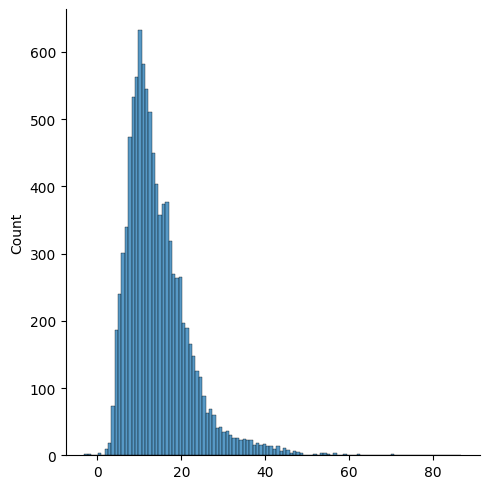

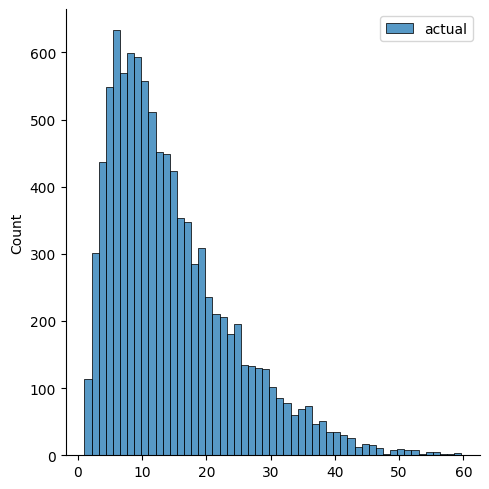

In [6]:
sns.displot(y_pred, label='prediction')
sns.displot(y_train, label='actual')

plt.legend()

In [7]:
def read_dataframe(filename):
    if filename.endswith('.csv'):
        df = pd.read_csv(filename, nrows=nrows)

        df.tpep_dropoff_datetime = pd.to_datetime(df.tpep_dropoff_datetime)
        df.tpep_pickup_datetime = pd.to_datetime(df.tpep_pickup_datetime)
    elif filename.endswith('.parquet'):
        df = pq.read_table(filename).slice(0, nrows).to_pandas()
        # df = pd.read_parquet(filename)

    df['duration'] = df.tpep_dropoff_datetime - df.tpep_pickup_datetime
    df.duration = df.duration.apply(lambda td: td.total_seconds() / 60)

    df = df[(df.duration >= 1) & (df.duration <= 60)]

    categorical = ['PULocationID', 'DOLocationID']
    df[categorical] = df[categorical].astype(str)
    
    return df

In [8]:
df_train = read_dataframe('data/yellow_tripdata_2023-01.parquet')
df_val = read_dataframe('data/yellow_tripdata_2023-02.parquet')

In [9]:
len(df_train), len(df_val)

(9837, 9668)

In [10]:
df_train['PU_DO'] = df_train['PULocationID'] + '_' + df_train['DOLocationID']
df_val['PU_DO'] = df_val['PULocationID'] + '_' + df_val['DOLocationID']

In [11]:
categorical = ['PU_DO'] #'PULocationID', 'DOLocationID']
numerical = ['trip_distance']

dv = DictVectorizer()

train_dicts = df_train[categorical + numerical].to_dict(orient='records')
X_train = dv.fit_transform(train_dicts)

val_dicts = df_val[categorical + numerical].to_dict(orient='records')
X_val = dv.transform(val_dicts)

In [12]:
target = 'duration'
y_train = df_train[target].values
y_val = df_val[target].values

In [13]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_val)

root_mean_squared_error(y_val, y_pred)

7.360644844115528

In [14]:
with open('model/lin_reg.bin', 'wb') as f_out:
    pickle.dump((dv, lr), f_out)

In [15]:
with mlflow.start_run():
    
    mlflow.set_tag("developer", "niltonpegass")
    mlflow.log_param("train-data-path", "data/green_tripdata_2021-01.parquet")
    mlflow.log_param("valid-data-path", "data/green_tripdata_2021-02.parquet")
    
    alpha = 0.01
    mlflow.log_param("alpha", alpha)

    # ##
    X_train.indices = X_train.indices.astype('int32')
    X_train.indptr = X_train.indptr.astype('int32')

    lr = Lasso(alpha)
    lr.fit(X_train, y_train)

    y_pred = lr.predict(X_val)

    rmse = root_mean_squared_error(y_val, y_pred)
    mlflow.log_metric("rmse", rmse)

2026/06/04 12:17:11 WARNING mlflow.utils.git_utils: Failed to import Git (the Git executable is probably not on your PATH), so Git SHA is not available. Error: Failed to initialize: Bad git executable.
The git executable must be specified in one of the following ways:
    - be included in your $PATH
    - be set via $GIT_PYTHON_GIT_EXECUTABLE
    - explicitly set via git.refresh(<full-path-to-git-executable>)

All git commands will error until this is rectified.

This initial message can be silenced or aggravated in the future by setting the
$GIT_PYTHON_REFRESH environment variable. Use one of the following values:
    - quiet|q|silence|s|silent|none|n|0: for no message or exception
    - warn|w|warning|log|l|1: for a warning message (logging level CRITICAL, displayed by default)
    - error|e|exception|raise|r|2: for a raised exception

Example:
    export GIT_PYTHON_REFRESH=quiet



#### TRAINING XGBOOST

In [ ]:
# -----------------------------------------------------------------------------
# SETUP NOTE (Python 3.14 + hyperopt 0.2.7 compatibility fix)
#
# hyperopt's atpe.py uses `pkg_resources`, which was dropped from setuptools>=81
# on Python 3.14. To reproduce this environment:
#
#   1. Ensure you are inside the pipenv virtualenv:
#        pipenv shell
#
#   2. Install a compatible setuptools version using the direct venv pip:
#        .local/share/virtualenvs/<your_venv_name>/bin/pip install "setuptools<81" --force-reinstall
#
#   3. Install hyperopt normally:
#        pipenv install hyperopt
#
#   The UserWarning about pkg_resources being deprecated is harmless for now.
#   Pin setuptools<81 until hyperopt releases a fix for this issue.
# -----------------------------------------------------------------------------

from hyperopt import fmin, tpe, hp, STATUS_OK, Trials
from hyperopt.pyll import scope

/home/niltonpegass/.local/share/virtualenvs/repositorio_local-WRNaRh7k/lib/python3.14/site-packages/hyperopt/atpe.py:19: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [17]:
train = xgb.DMatrix(X_train, label=y_train)
valid = xgb.DMatrix(X_val, label=y_val)

In [21]:
def objective(params):
    with mlflow.start_run():
        mlflow.set_tag("model", "xgboost")
        mlflow.log_params(params)
        booster = xgb.train(
            params=params,
            dtrain=train,
            num_boost_round=100,
            evals=[(valid, 'validation')],
            early_stopping_rounds=50
        )
        y_pred = booster.predict(valid)
        # rmse = root_mean_squared_error(y_val, y_pred, squared=False)
        rmse = root_mean_squared_error(y_val, y_pred)
        mlflow.log_metric("rmse", rmse)

    return {'loss': rmse, 'status': STATUS_OK}

In [22]:
search_space = {
    'max_depth': scope.int(hp.quniform('max_depth', 4, 50, 1)),
    'learning_rate': hp.loguniform('learning_rate', -2, 0),
    'reg_alpha': hp.loguniform('reg_alpha', -2, -1),
    'reg_lambda': hp.loguniform('reg_lambda', -4, -1),
    'min_child_weight': hp.loguniform('min_child_weight', -1, 2),
    'objective': 'reg:linear',
    'seed': 42
}

best_result = fmin(
    fn=objective,
    space=search_space,
    algo=tpe.suggest,
    max_evals=50,
    trials=Trials()
)

[0]	validation-rmse:6.99698                           
[1]	validation-rmse:5.96141                           
[2]	validation-rmse:5.67607                           
[3]	validation-rmse:5.62289                           
[4]	validation-rmse:5.61693                           
  0%|          | 0/50 [00:00<?, ?trial/s, best loss=?]

/home/niltonpegass/.local/share/virtualenvs/repositorio_local-WRNaRh7k/lib/python3.14/site-packages/xgboost/callback.py:385: UserWarning: [12:23:50] WARNING: /__w/xgboost/xgboost/src/objective/regression_obj.cu:277: reg:linear is now deprecated in favor of reg:squarederror.
  self.starting_round = model.num_boosted_rounds()



[5]	validation-rmse:5.62539                           
[6]	validation-rmse:5.63841                           
[7]	validation-rmse:5.65171                           
[8]	validation-rmse:5.65871                           
[9]	validation-rmse:5.67269                           
[10]	validation-rmse:5.67811                          
[11]	validation-rmse:5.68533                          
[12]	validation-rmse:5.69236                          
[13]	validation-rmse:5.69769                          
[14]	validation-rmse:5.70164                          
[15]	validation-rmse:5.70542                          
[16]	validation-rmse:5.71106                          
[17]	validation-rmse:5.71417                          
[18]	validation-rmse:5.72027                          
[19]	validation-rmse:5.72225                          
[20]	validation-rmse:5.72664                          
[21]	validation-rmse:5.73050                          
[22]	validation-rmse:5.73409                          
[23]	valid

/home/niltonpegass/.local/share/virtualenvs/repositorio_local-WRNaRh7k/lib/python3.14/site-packages/xgboost/callback.py:385: UserWarning: [12:23:52] WARNING: /__w/xgboost/xgboost/src/objective/regression_obj.cu:277: reg:linear is now deprecated in favor of reg:squarederror.
  self.starting_round = model.num_boosted_rounds()



[15]	validation-rmse:5.69023                                                    
[16]	validation-rmse:5.69238                                                    
[17]	validation-rmse:5.69218                                                    
[18]	validation-rmse:5.69276                                                    
[19]	validation-rmse:5.69304                                                    
[20]	validation-rmse:5.70091                                                    
[21]	validation-rmse:5.70001                                                    
[22]	validation-rmse:5.70216                                                    
[23]	validation-rmse:5.70126                                                    
[24]	validation-rmse:5.70138                                                    
[25]	validation-rmse:5.70076                                                    
[26]	validation-rmse:5.70325                                                    
[27]	validation-rmse:5.70524

...

[9]	validation-rmse:5.76439                                                     
[10]	validation-rmse:5.69094                                                    
[11]	validation-rmse:5.64956                                                    
[12]	validation-rmse:5.62766                                                    
[13]	validation-rmse:5.60174                                                    
[14]	validation-rmse:5.60267                                                    
[15]	validation-rmse:5.58675                                                    
[16]	validation-rmse:5.57908                                                    
[17]	validation-rmse:5.57553                                                    
[18]	validation-rmse:5.58838                                                    
[19]	validation-rmse:5.58752                                                    
[20]	validation-rmse:5.58386                                                    
[21]	validation-rmse:5.58538

/home/niltonpegass/.local/share/virtualenvs/repositorio_local-WRNaRh7k/lib/python3.14/site-packages/xgboost/callback.py:385: UserWarning: [12:25:31] WARNING: /__w/xgboost/xgboost/src/objective/regression_obj.cu:277: reg:linear is now deprecated in favor of reg:squarederror.
  self.starting_round = model.num_boosted_rounds()



[18]	validation-rmse:5.63246                                                    
[19]	validation-rmse:5.63179                                                    
[20]	validation-rmse:5.63265                                                    
[21]	validation-rmse:5.63401                                                    
[22]	validation-rmse:5.63464                                                    
[23]	validation-rmse:5.63739                                                    
[24]	validation-rmse:5.64236                                                    
[25]	validation-rmse:5.64411                                                    
[26]	validation-rmse:5.64812                                                    
[27]	validation-rmse:5.64805                                                    
[28]	validation-rmse:5.65156                                                    
[29]	validation-rmse:5.65559                                                    
[30]	validation-rmse:5.65510

/home/niltonpegass/.local/share/virtualenvs/repositorio_local-WRNaRh7k/lib/python3.14/site-packages/xgboost/callback.py:385: UserWarning: [12:25:32] WARNING: /__w/xgboost/xgboost/src/objective/regression_obj.cu:277: reg:linear is now deprecated in favor of reg:squarederror.
  self.starting_round = model.num_boosted_rounds()



[6]	validation-rmse:5.67688                                                     
[7]	validation-rmse:5.79936                                                     
[8]	validation-rmse:5.80968                                                     
[9]	validation-rmse:5.81324                                                     
[10]	validation-rmse:5.82291                                                    
[11]	validation-rmse:5.83036                                                    
[12]	validation-rmse:5.83280                                                    
[13]	validation-rmse:5.83961                                                    
[14]	validation-rmse:5.84303                                                    
[15]	validation-rmse:5.84105                                                    
[16]	validation-rmse:5.84599                                                    
[17]	validation-rmse:5.84850                                                    
[18]	validation-rmse:5.84812